In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/smirkxd/titanic-dataset/titanic.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

https://www.kaggle.com/datasets/smirkxd/titanic-dataset

In [3]:
data = pd.read_csv('/kaggle/input/datasets/smirkxd/titanic-dataset/titanic.csv')
df = pd.DataFrame(data)

## 1. Understanding Data

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.shape

(891, 12)

In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [11]:
df.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


## 2. Data Cleaning

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
# Filling Missing Values
# Group by Class and Sex, then fill missing ages with that specific group's median
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [14]:
# Removing Ireelevant Columns
df = df.drop(['PassengerId', 'Name', 'Ticket','Cabin'], axis=1)

## 3. EDA

### 3.1 Univariate Analysis

<Axes: xlabel='Survived', ylabel='count'>

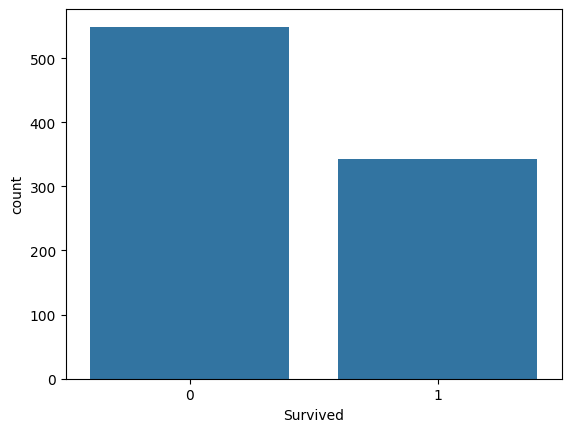

In [15]:
sns.countplot(x = df["Survived"])

This shows more than 50% of the passangers are not survived

<Axes: xlabel='Pclass', ylabel='count'>

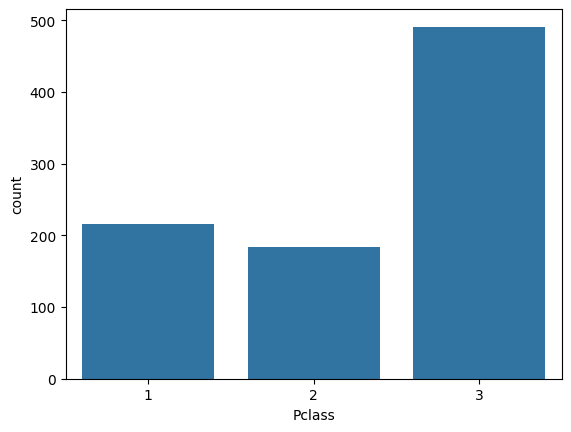

In [16]:
sns.countplot(x = df["Pclass"])

<Axes: xlabel='Sex', ylabel='count'>

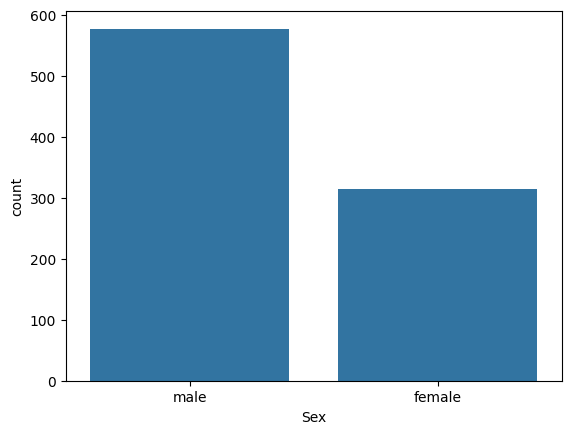

In [17]:
sns.countplot(x = df['Sex'])

This shows dataset contains more male

<Axes: xlabel='Age', ylabel='Count'>

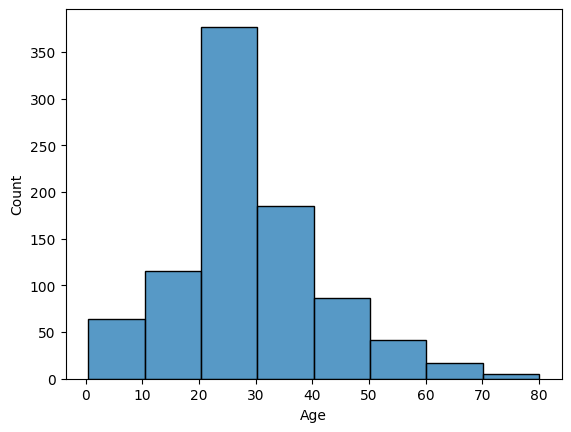

In [18]:
sns.histplot(df['Age'],bins=8)

<Axes: xlabel='SibSp', ylabel='count'>

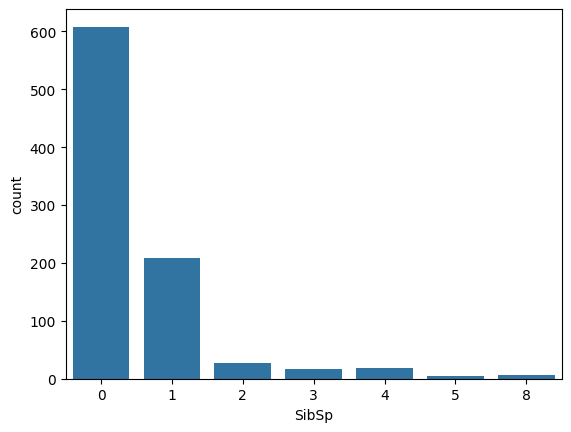

In [19]:
sns.countplot(x = df['SibSp'])

<Axes: xlabel='Parch', ylabel='count'>

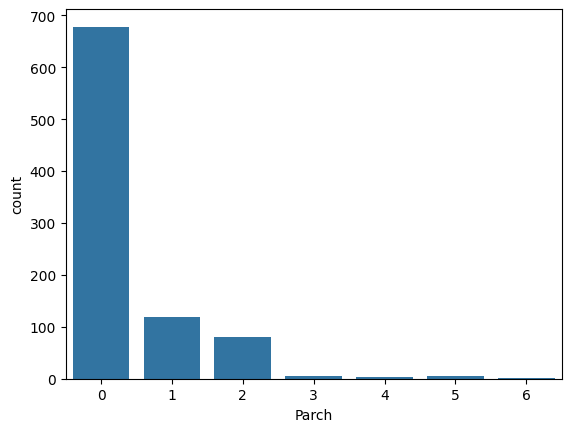

In [20]:
sns.countplot(x = df['Parch'])

<Axes: xlabel='Fare'>

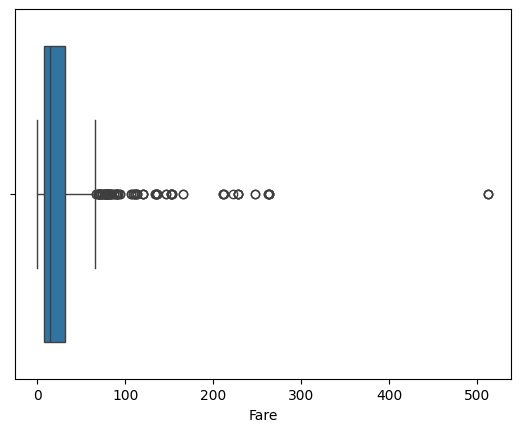

In [21]:
sns.boxplot(x = df['Fare'])

Because Fare is highly right - skewed we use lop1p

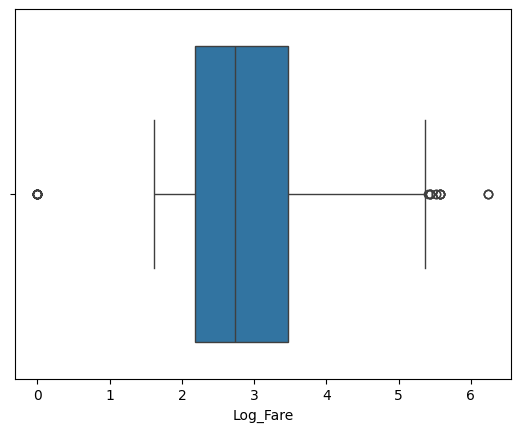

In [22]:
# Apply log transformation
df['Log_Fare'] = np.log1p(df['Fare'])

# Dropping the Fare Column
df = df.drop(columns='Fare')
# Check the new distribution
sns.boxplot(x=df['Log_Fare'])
plt.show()

<Axes: xlabel='Embarked', ylabel='count'>

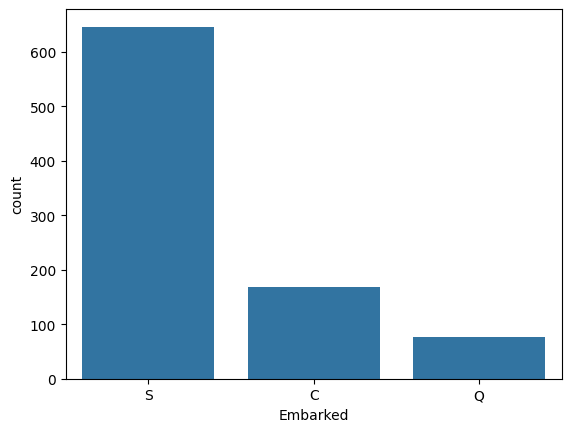

In [23]:
sns.countplot(x = df['Embarked'])

### 3.2 Bivariate Analysis

Survived          0          1
Sex                           
female    25.796178  74.203822
male      81.109185  18.890815


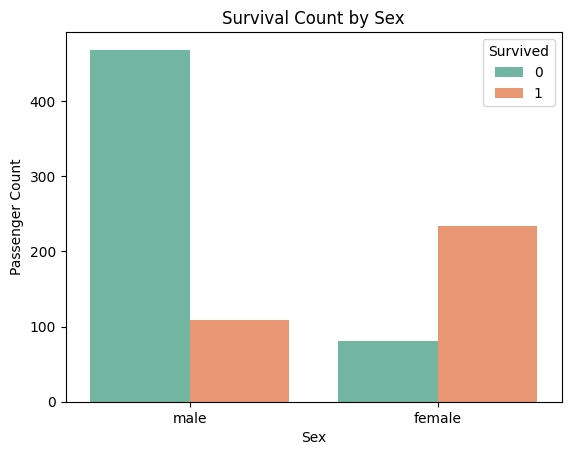

In [24]:
# Sex vs. Survived (Categorical vs. Categorical)
print(pd.crosstab(df['Sex'], df['Survived'], normalize='index') * 100)

sns.countplot(x='Sex', hue='Survived', data=df, palette='Set2')
plt.title('Survival Count by Sex')
plt.xlabel('Sex')
plt.ylabel('Passenger Count')
plt.show()

Survived          0          1
Pclass                        
1         37.037037  62.962963
2         52.717391  47.282609
3         75.763747  24.236253


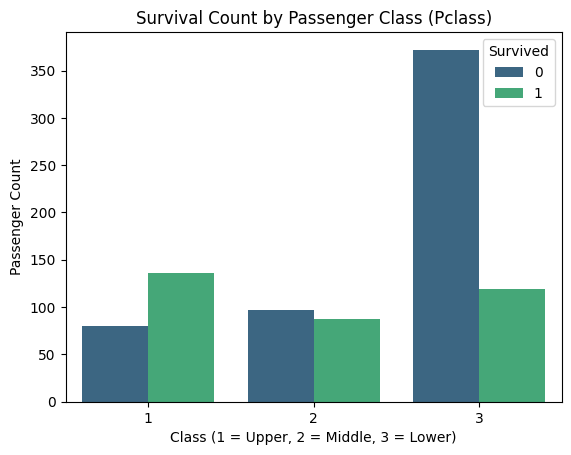

In [25]:
# Pclass vs. Survived (Categorical vs. Categorical)
print(pd.crosstab(df['Pclass'], df['Survived'], normalize='index') * 100)

sns.countplot(x='Pclass', hue='Survived', data=df, palette='viridis')
plt.title('Survival Count by Passenger Class (Pclass)')
plt.xlabel('Class (1 = Upper, 2 = Middle, 3 = Lower)')
plt.ylabel('Passenger Count')
plt.show()

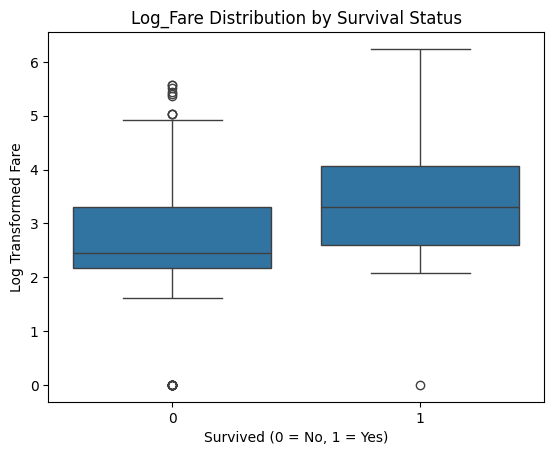

In [26]:
# Log_Fare vs. Survived (Numerical vs. Categorical)
# Used To confirm if passengers who paid higher fares had a better chance of survival using your newly transformed, balanced feature.
sns.boxplot(x='Survived', y='Log_Fare', data=df)
plt.title('Log_Fare Distribution by Survival Status')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Log Transformed Fare')
plt.show()

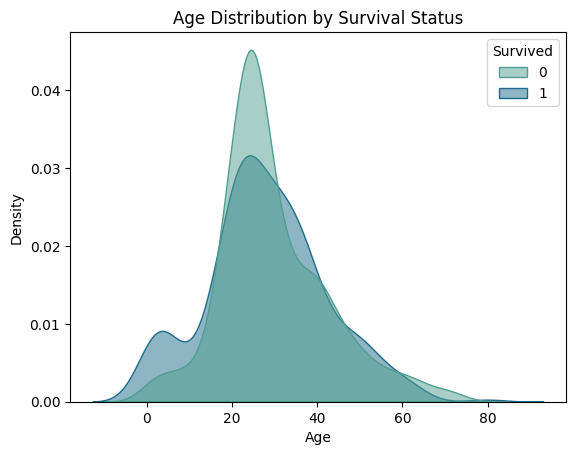

In [27]:
# Age vs. Survived (Numerical vs. Categorical)
sns.kdeplot(data=df, x='Age', hue='Survived', fill=True, common_norm=False, palette='crest', alpha=0.5)
plt.title('Age Distribution by Survival Status')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

/tmp/ipykernel_16/467309000.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Family_Size', y='Survived', data=df, errorbar=None, palette='magma')


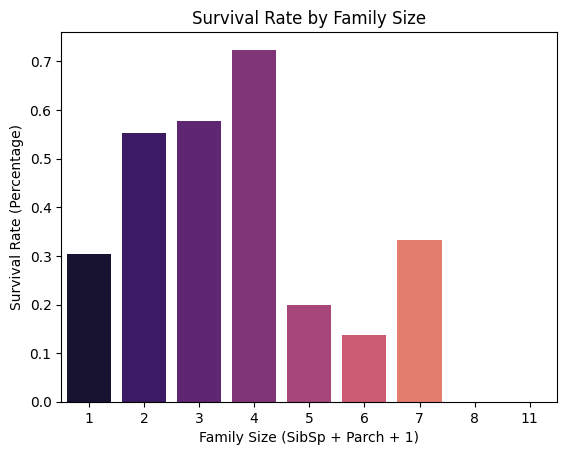

In [28]:
# Family Size (SibSp & Parch) vs. Survived
# Create a temporary family size feature for analysis
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1

sns.barplot(x='Family_Size', y='Survived', data=df, errorbar=None, palette='magma')
plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size (SibSp + Parch + 1)')
plt.ylabel('Survival Rate (Percentage)')
plt.show()

# Drop the temporary column if you don't want to keep it yet
df = df.drop(columns=['Family_Size'])

Survived          0          1
Embarked                      
C         44.642857  55.357143
Q         61.038961  38.961039
S         66.099071  33.900929


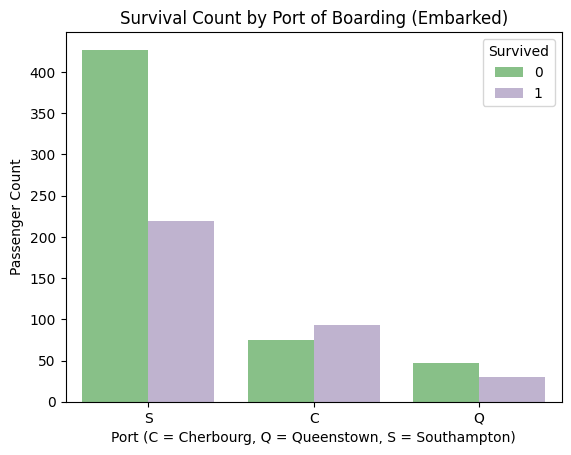

In [29]:
# Embarked vs. Survived (Categorical vs. Categorical)
print(pd.crosstab(df['Embarked'], df['Survived'], normalize='index') * 100)

sns.countplot(x='Embarked', hue='Survived', data=df, palette='Accent')
plt.title('Survival Count by Port of Boarding (Embarked)')
plt.xlabel('Port (C = Cherbourg, Q = Queenstown, S = Southampton)')
plt.ylabel('Passenger Count')
plt.show()

### 3.3 Bivariate Analysis

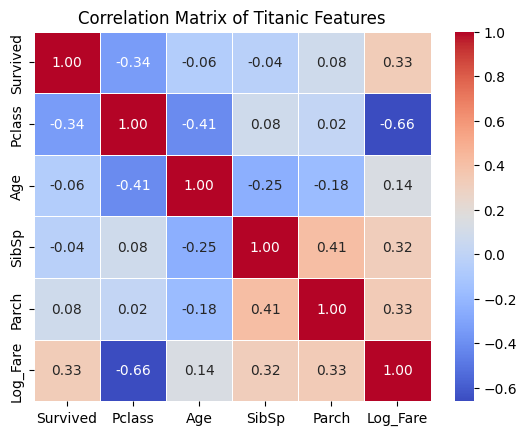

In [30]:
# Select only numerical columns for correlation
numerical_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Log_Fare']
corr_matrix = df[numerical_cols].corr()

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Titanic Features')
plt.show()

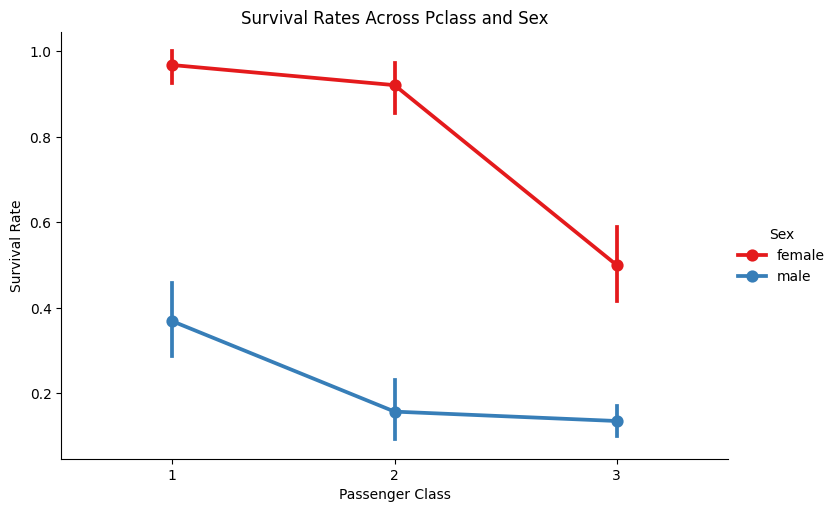

In [31]:
# Catplot allows us to break down categories cleanly
sns.catplot(x='Pclass', y='Survived', hue='Sex', kind='point', data=df, palette='Set1', height=5, aspect=1.5)
plt.title('Survival Rates Across Pclass and Sex')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

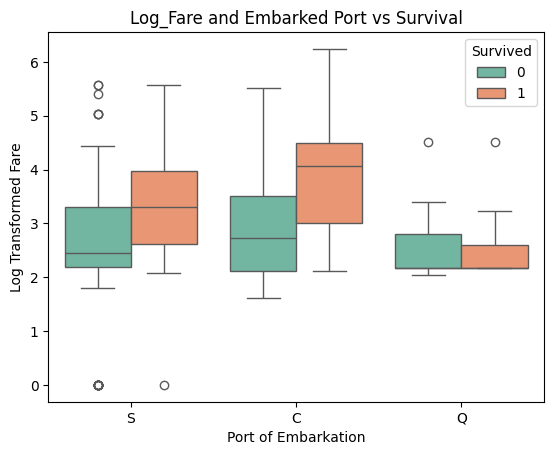

In [32]:
# Log_Fare + Embarked vs. Survived (Num + Cat + Cat)
sns.boxplot(x='Embarked', y='Log_Fare', hue='Survived', data=df, palette='Set2')
plt.title('Log_Fare and Embarked Port vs Survival')
plt.xlabel('Port of Embarkation')
plt.ylabel('Log Transformed Fare')
plt.show()

## 4. Feature Transformation

In [33]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split

### 4.1 One-Hot Encoding 

In [34]:
# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True, dtype=int)

# View the new columns
df_encoded.head()

,Survived,Pclass,Age,SibSp,Parch,Log_Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,2.110213,1,0,1
1,1,1,38.0,1,0,4.280593,0,0,0
2,1,3,26.0,0,0,2.188856,0,0,1
3,1,1,35.0,1,0,3.990834,0,0,1
4,0,3,35.0,0,0,2.202765,1,0,1


### 4.2 Split Dataset for Training and Testing

In [35]:
# Splitting data so test data remained untouched
X = df_encoded.drop('Survived',axis=1)
y = df_encoded['Survived']

In [36]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

### 4.3 Scaling Data

In [37]:
df_encoded.head()

,Survived,Pclass,Age,SibSp,Parch,Log_Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,2.110213,1,0,1
1,1,1,38.0,1,0,4.280593,0,0,0
2,1,3,26.0,0,0,2.188856,0,0,1
3,1,1,35.0,1,0,3.990834,0,0,1
4,0,3,35.0,0,0,2.202765,1,0,1


In [38]:
# 1. Initialize the scaler
scaler = StandardScaler()

# 2. Define the columns you want to scale
columns_to_scale = ['Age', 'Log_Fare']

# 3. Scale X_train and X_test directly in-place
X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

In [39]:
X_train.head()

,Pclass,Age,SibSp,Parch,Log_Fare,Sex_male,Embarked_Q,Embarked_S
331,1,1.249288,0,0,0.437404,1,0,1
733,2,-0.445751,0,0,-0.322935,1,0,1
382,3,0.232265,0,0,-0.782201,1,0,1
704,3,-0.219746,1,0,-0.790325,1,0,1
813,3,-1.726446,4,2,0.529116,0,0,1


## 5. Machine Learning

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier       
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix 

In [41]:
# Initialize all classifiers directly inside a structured dictionary
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Neighbors Classifier': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Support Vector Machine': SVC(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, eval_metric='logloss')
}

In [42]:
# Dictionary to store accuracy scores for comparison
accuracy_scores = {}

# Loop through each model
for name, model in models.items():
    # 1. Fit the model on the training data
    model.fit(X_train, y_train)
    
    # 2. Make predictions on the test data
    y_pred = model.predict(X_test)
    
    # 3. Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    accuracy_scores[name] = acc
    
    # 4. Print individual model performance
    print(f"=== {name} ===")
    print(f"Accuracy Score: {acc:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

=== Logistic Regression ===
Accuracy Score: 0.8212

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

--------------------------------------------------
=== K-Neighbors Classifier ===
Accuracy Score: 0.7989

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       105
           1       0.76      0.74      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

--------------------------------------------------
=== Decision Tree ===
Accuracy Score: 0.7877

Classification Report:
              precisio

In [43]:
# Convert scores to a DataFrame for clean visualization
df_comparison = pd.DataFrame(list(accuracy_scores.items()), columns=['Model', 'Accuracy'])
df_comparison = df_comparison.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print("🏆 Model Comparison Leaderboard 🏆")
print(df_comparison)

🏆 Model Comparison Leaderboard 🏆
                    Model  Accuracy
0     Logistic Regression  0.821229
1                 XGBoost  0.821229
2       Gradient Boosting  0.821229
3  Support Vector Machine  0.815642
4           Random Forest  0.810056
5  K-Neighbors Classifier  0.798883
6           Decision Tree  0.787709


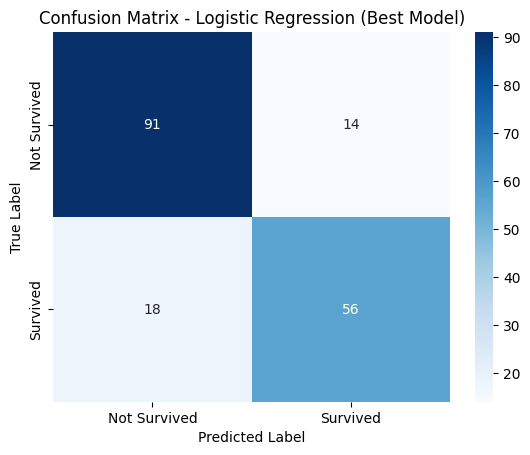

In [44]:
# 1. Get the name of the best model from our comparison DataFrame
best_model_name = df_comparison.iloc[0]['Model']
best_model = models[best_model_name]

# 2. Generate predictions using the best model
y_pred_best = best_model.predict(X_test)

# 3. Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# 4. Plot using Seaborn heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Survived', 'Survived'], 
            yticklabels=['Not Survived', 'Survived'])

plt.title(f'Confusion Matrix - {best_model_name} (Best Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

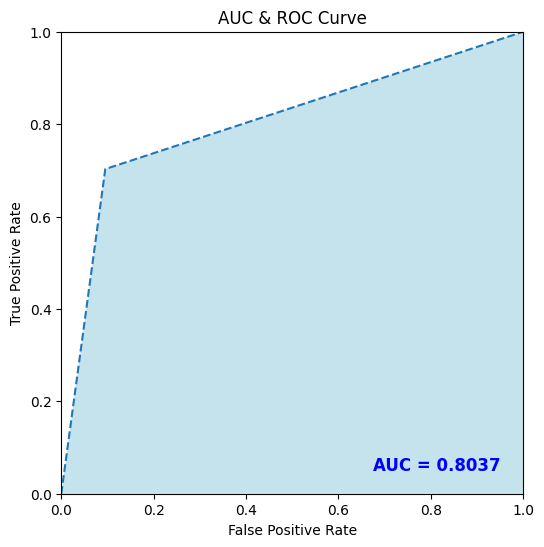

In [45]:
from sklearn import metrics
auc = metrics.roc_auc_score(y_test, y_pred)

false_positive_rate, true_positive_rate, thresolds = metrics.roc_curve(y_test, y_pred)

plt.figure(figsize=(6, 6), dpi=100)
plt.axis('scaled')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.title("AUC & ROC Curve")
plt.plot(false_positive_rate, true_positive_rate,'--' )
plt.fill_between(false_positive_rate, true_positive_rate, facecolor='lightblue', alpha=0.7)
plt.text(0.95, 0.05, 'AUC = %0.4f' % auc, ha='right', fontsize=12, weight='bold', color='blue')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

### Hope you like my work and don't forgot to upvote me :)